

# Dependencies



In [14]:
# !pip -q install transformers sentence-transformers accelerate
# !pip -q install optuna
import optuna
import numpy as np
import pandas as pd
import textwrap, json, re
import os, zipfile, urllib.request
from dataclasses import dataclass
from typing import List, Dict, Any, Tuple
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sentence_transformers import SentenceTransformer
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Data Preparation (MovieLens)

In [15]:
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ML100K_DIR = DATA_DIR / "ml-100k"
URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_path = DATA_DIR / "ml-100k.zip"

if not ML100K_DIR.exists():
    if not zip_path.exists():
        print("Downloading MovieLens 100K...")
        urllib.request.urlretrieve(URL, zip_path.as_posix())
    else:
        print("Zip already downloaded:", zip_path)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

print("Using data directory:", ML100K_DIR)
print("Top-level contents:", list(DATA_DIR.iterdir())[:5])

ratings_path = ML100K_DIR / "u.data"
# u.data format: user_id \t item_id \t rating \t timestamp
ratings = pd.read_csv(
    ratings_path,
    sep="\t",
    header=None,
    names=["user_id", "item_id", "rating", "timestamp"],
)

ratings.head(), ratings.shape

# Create contiguous indices for users and items
user_ids = ratings["user_id"].unique()
item_ids = ratings["item_id"].unique()

user2idx = {u: i for i, u in enumerate(sorted(user_ids))}
item2idx = {m: i for i, m in enumerate(sorted(item_ids))}

ratings["u"] = ratings["user_id"].map(user2idx).astype(int)
ratings["i"] = ratings["item_id"].map(item2idx).astype(int)

n_users = len(user2idx)
n_items = len(item2idx)

print("n_users:", n_users, "n_items:", n_items)
ratings[["u", "i", "rating"]].head()

rng = np.random.default_rng(42)
idx = np.arange(len(ratings))
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx = idx[:split]
test_idx = idx[split:]

train = ratings.iloc[train_idx].reset_index(drop=True)
test = ratings.iloc[test_idx].reset_index(drop=True)

print("Train size:", len(train), "Test size:", len(test))

# Convert to numpy arrays for fast loops
train_u = train["u"].to_numpy(np.int64)
train_i = train["i"].to_numpy(np.int64)
train_r = train["rating"].to_numpy(np.float32)

test_u = test["u"].to_numpy(np.int64)
test_i = test["i"].to_numpy(np.int64)
test_r = test["rating"].to_numpy(np.float32)

train_u, val_u, train_i, val_i, train_r, val_r = train_test_split(
    train_u, train_i, train_r, test_size=0.2, random_state=42
)

Using data directory: ..\data\ml-100k
Top-level contents: [WindowsPath('../data/ml-100k'), WindowsPath('../data/README.md')]
n_users: 943 n_items: 1682
Train size: 80000 Test size: 20000


# Baseline global mean


In [16]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


mu = float(train_r.mean())
baseline_pred = np.full_like(test_r, mu, dtype=np.float32)

print("Global-mean baseline RMSE:", rmse(test_r, baseline_pred))

Global-mean baseline RMSE: 1.1331379413604736


# Build per-user and per-item interaction lists (useful for ALS)

In [17]:
def user_item_ratings(train_u, train_i, train_r):
    user_ratings = defaultdict(list)
    item_ratings = defaultdict(list)
    item_popularity = defaultdict(int)

    for u, i, r in zip(train_u, train_i, train_r):
        user_ratings[int(u)].append((int(i), float(r)))
        item_ratings[int(i)].append((int(u), float(r)))
        item_popularity[int(i)] += 1
    return user_ratings, item_ratings, item_popularity

# [MF-Methods] - Initialization

In [18]:
d = 20
lam = 0.05

rng = np.random.default_rng(0)
P = 0.1 * rng.standard_normal((n_users, d)).astype(np.float32)
Q = 0.1 * rng.standard_normal((n_items, d)).astype(np.float32)
bu = np.zeros(n_users, dtype=np.float32)
bi = np.zeros(n_items, dtype=np.float32)
user_ratings, item_ratings, item_popularity = user_item_ratings(
    train_u, train_i, train_r
)

# [MF-METHODS] - Save best state to use later

In [19]:
from pathlib import Path
import json
import numpy as np

def save_mf_state(path, *, P, Q, bu, bi, mu, d, model_name, lam=None, lam_factors=None, lam_biases=None, extra=None):
    if lam is None and lam_factors is None:
        raise ValueError("Provide either lam or lam_factors")
    _lam = lam if lam is not None else lam_factors
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        path,
        P=P,
        Q=Q,
        bu=bu,
        bi=bi,
        mu=np.array(mu, dtype=np.float32),
        d=np.array(d, dtype=np.int32),
        lam=np.array(_lam, dtype=np.float32),
    )

    meta = {
        "model_name": model_name,
        "d": int(d),
        "lam": float(_lam),
        "mu": float(mu),
    }
    if lam_factors is not None:
        meta["lam_factors"] = float(lam_factors)
    if lam_biases is not None:
        meta["lam_biases"] = float(lam_biases)
    if extra is not None:
        meta["extra"] = extra

    with open(path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)


def load_mf_state(path):
    path = Path(path)
    data = np.load(path, allow_pickle=False)
    with open(path.with_suffix(".json"), "r") as f:
        meta = json.load(f)

    return {
        "P": data["P"],
        "Q": data["Q"],
        "bu": data["bu"],
        "bi": data["bi"],
        "mu": float(data["mu"]),
        "d": int(data["d"]),
        "lam": float(data["lam"]),
        "meta": meta,
    }

# [MF-Methods] - Helpers

In [20]:
def predict(u, i, mu, bu, bi, P, Q):
    return mu + bu[u] + bi[i] + float(P[u] @ Q[i])


def batch_predict(u_arr, i_arr, mu, bu, bi, P, Q):
    out = np.empty(len(u_arr), dtype=np.float32)
    for k, (u, i) in enumerate(zip(u_arr, i_arr)):
        out[k] = mu + bu[u] + bi[i] + float(P[u] @ Q[i])
    return out


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mf_predict(u_arr, i_arr, mu, bu, bi, P, Q):
    return mu + bu[u_arr] + bi[i_arr] + np.einsum("nd,nd->n", P[u_arr], Q[i_arr])


def mf_score(u, i, mu, bu, bi, P, Q):
    return float(mu + bu[u] + bi[i] + P[u] @ Q[i])

# [MF-Methods] - SGD (Implementation)


In [21]:
def train_sgd_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    d=20, lam_factors=0.05, lam_biases=0.05, eta=0.01, epochs=20,
    seed=0, save_path=None
):
    rng = np.random.default_rng(seed)
    P = (0.1 * rng.standard_normal((n_users, d))).astype(np.float32)
    Q = (0.1 * rng.standard_normal((n_items, d))).astype(np.float32)
    bu = np.zeros(n_users, dtype=np.float32)
    bi = np.zeros(n_items, dtype=np.float32)

    mu = float(train_r.mean())

    best = {
        "val_rmse": float("inf"),
        "P": None, "Q": None, "bu": None, "bi": None,
        "epoch": None,
    }

    train_curve, val_curve = [], []

    for ep in range(1, epochs + 1):
        order = rng.permutation(len(train_u))
        for k in order:
            u, i, r = int(train_u[k]), int(train_i[k]), float(train_r[k])
            pred = mu + bu[u] + bi[i] + float(P[u] @ Q[i])
            err = r - pred

            # keep old Pu if you want a more "standard" SGD update
            pu_old = P[u].copy()

            bu[u] += eta * (err - lam_biases * bu[u])
            bi[i] += eta * (err - lam_biases * bi[i])
            P[u] += eta * (err * Q[i] - lam_factors * P[u])
            Q[i] += eta * (err * pu_old - lam_factors * Q[i])

        tr_rmse = rmse(train_r, mf_predict(train_u, train_i, mu, bu, bi, P, Q))
        va_rmse = rmse(val_r, mf_predict(val_u, val_i, mu, bu, bi, P, Q))
        train_curve.append(tr_rmse)
        val_curve.append(va_rmse)

        if va_rmse < best["val_rmse"]:
            best["val_rmse"] = va_rmse
            best["P"] = P.copy()
            best["Q"] = Q.copy()
            best["bu"] = bu.copy()
            best["bi"] = bi.copy()
            best["epoch"] = ep

        print(f"Epoch {ep:02d} | train RMSE={tr_rmse:.4f} | val RMSE={va_rmse:.4f}")

    best_state = {
        "P": best["P"],
        "Q": best["Q"],
        "bu": best["bu"],
        "bi": best["bi"],
        "mu": mu,
        "d": d,
        "lam_biases": lam_biases,
        "lam_factors": lam_factors,
        "best_epoch": best["epoch"],
        "train_curve": train_curve,
        "val_curve": val_curve,
    }

    if save_path is not None:
        save_mf_state(
            save_path,
            P=best_state["P"],
            Q=best_state["Q"],
            bu=best_state["bu"],
            bi=best_state["bi"],
            mu=best_state["mu"],
            d=best_state["d"],
            lam_factors=best_state["lam_factors"],
            lam_biases=best_state["lam_biases"],
            model_name="sgd_mf",
            extra={"best_epoch": best_state["best_epoch"]}
        )

    return best_state

# [MF-Methods] - SGD (tuning)

In [22]:
def tune_sgd(n_trials=50):
    
    def objective(trial):
        d = trial.suggest_int("d", 20, 120)
        lam_biases = trial.suggest_float("lam_biases", 1e-4, 0.05, log=True)
        lam_factors = trial.suggest_float("lam_factors", 0.01, 0.3, log=True)
        eta = trial.suggest_float("eta", 0.002, 0.03, log=True)
        epochs = trial.suggest_int("epochs", 10, 80)
        state = train_sgd_mf(
            train_u,
            train_i,
            train_r,
            val_u,
            val_i,
            val_r,
            n_users,
            n_items,
            d,
            lam_factors,
            lam_biases,
            eta,
            epochs,
        )
        val_rmse = min(state["val_curve"])
        return val_rmse
    
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print("\nBest parameters:")
    print(study.best_params)

    print("\nBest validation RMSE:")
    print(study.best_value)

    return study.best_params

# [MF-Methods] - ALS (implementation)

In [23]:
def train_als_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    user_ratings, item_ratings,
    d=20, lam=0.05, iters=5,
    seed=0, save_path=None
):
    rng = np.random.default_rng(seed)
    P = (0.1 * rng.standard_normal((n_users, d))).astype(np.float32)
    Q = (0.1 * rng.standard_normal((n_items, d))).astype(np.float32)
    bu = np.zeros(n_users, dtype=np.float32)
    bi = np.zeros(n_items, dtype=np.float32)

    mu = float(train_r.mean())
    I = np.eye(d, dtype=np.float32)

    best = {
        "val_rmse": float("inf"),
        "P": None, "Q": None, "bu": None, "bi": None,
        "iter": None,
    }

    train_curve, val_curve = [], []

    for it in range(1, iters + 1):
        # update user factors
        for u in range(n_users):
            items = user_ratings.get(u, [])
            if not items:
                continue
            A = lam * I
            b = np.zeros(d, dtype=np.float32)
            for i, r in items:
                qi = Q[i]
                A += np.outer(qi, qi)
                b += (r - mu - bu[u] - bi[i]) * qi
            P[u] = np.linalg.solve(A, b)

        # update item factors
        for i in range(n_items):
            users = item_ratings.get(i, [])
            if not users:
                continue
            A = lam * I
            b = np.zeros(d, dtype=np.float32)
            for u, r in users:
                pu = P[u]
                A += np.outer(pu, pu)
                b += (r - mu - bu[u] - bi[i]) * pu
            Q[i] = np.linalg.solve(A, b)

        # update biases
        for u in range(n_users):
            items = user_ratings.get(u, [])
            if not items:
                continue
            num = 0.0
            for i, r in items:
                num += r - mu - bi[i] - P[u] @ Q[i]
            bu[u] = num / (lam + len(items))

        for i in range(n_items):
            users = item_ratings.get(i, [])
            if not users:
                continue
            num = 0.0
            for u, r in users:
                num += r - mu - bu[u] - P[u] @ Q[i]
            bi[i] = num / (lam + len(users))

        tr_rmse = rmse(train_r, batch_predict(train_u, train_i, mu, bu, bi, P, Q))
        va_rmse = rmse(val_r, batch_predict(val_u, val_i, mu, bu, bi, P, Q))
        train_curve.append(tr_rmse)
        val_curve.append(va_rmse)

        if va_rmse < best["val_rmse"]:
            best["val_rmse"] = va_rmse
            best["P"] = P.copy()
            best["Q"] = Q.copy()
            best["bu"] = bu.copy()
            best["bi"] = bi.copy()
            best["iter"] = it

        print(f"ALS iter {it:02d} | train RMSE={tr_rmse:.4f} | val RMSE={va_rmse:.4f}")

    best_state = {
        "P": best["P"],
        "Q": best["Q"],
        "bu": best["bu"],
        "bi": best["bi"],
        "mu": mu,
        "d": d,
        "lam": lam,
        "best_iter": best["iter"],
        "train_curve": train_curve,
        "val_curve": val_curve,
    }

    if save_path is not None:
        save_mf_state(
            save_path,
            P=best_state["P"],
            Q=best_state["Q"],
            bu=best_state["bu"],
            bi=best_state["bi"],
            mu=best_state["mu"],
            d=best_state["d"],
            lam=best_state["lam"],
            model_name="als_mf",
            extra={"best_iter": best_state["best_iter"]}
        )

    return best_state

# [MF-Methods] - ALS (tuning)

In [24]:
def tune_als(n_trials=40):

    def objective(trial):
        d = trial.suggest_int("d", 10, 150)
        lam = trial.suggest_float(
            "lam",
            1e-3,
            10.0,
            log=True
        )
        iters = trial.suggest_int("iters", 2, 25)
        state = train_als_mf(
            train_u,
            train_i,
            train_r,
            val_u,
            val_i,
            val_r,
            n_users,
            n_items,
            user_ratings,
            item_ratings,
            d,
            lam,
            iters
        )
        val_rmse = min(state["val_curve"])
        return val_rmse


    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    print("\nBest ALS params:")
    print(study.best_params)

    print("\nBest validation RMSE:")
    print(study.best_value)

    return study.best_params

# [MF-Methods] - train


In [25]:
# sgd_best_params = tune_sgd()
sgd_best_params = {
    'd': 81,
    'lam_biases': 0.0005274432500432459,
    'lam_factors': 0.11381526595226511,
    'eta': 0.011638537448331186,
    'epochs': 75
}
# als_best_params = tune_als()
als_best_params = {
    'd': 131,
    'lam': 9.71633075356387,
    'iters': 15
}

sgd_state = train_sgd_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    d=sgd_best_params['d'], lam_factors=sgd_best_params['lam_factors'], lam_biases=sgd_best_params['lam_biases'], eta=sgd_best_params['eta'], epochs=sgd_best_params['epochs'],
    save_path="artifacts/sgd_mf_best.npz"
)

als_state = train_als_mf(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_items,
    user_ratings, item_ratings,
    d=als_best_params['d'], lam=als_best_params['lam'], iters=als_best_params['iters'],
    save_path="artifacts/als_mf_best.npz"
)

Epoch 01 | train RMSE=0.9513 | val RMSE=0.9868
Epoch 02 | train RMSE=0.9186 | val RMSE=0.9672
Epoch 03 | train RMSE=0.9028 | val RMSE=0.9593
Epoch 04 | train RMSE=0.8929 | val RMSE=0.9554
Epoch 05 | train RMSE=0.8859 | val RMSE=0.9527
Epoch 06 | train RMSE=0.8802 | val RMSE=0.9512
Epoch 07 | train RMSE=0.8753 | val RMSE=0.9500
Epoch 08 | train RMSE=0.8704 | val RMSE=0.9493
Epoch 09 | train RMSE=0.8657 | val RMSE=0.9471
Epoch 10 | train RMSE=0.8608 | val RMSE=0.9463
Epoch 11 | train RMSE=0.8556 | val RMSE=0.9453
Epoch 12 | train RMSE=0.8500 | val RMSE=0.9447
Epoch 13 | train RMSE=0.8441 | val RMSE=0.9431
Epoch 14 | train RMSE=0.8379 | val RMSE=0.9414
Epoch 15 | train RMSE=0.8316 | val RMSE=0.9400
Epoch 16 | train RMSE=0.8246 | val RMSE=0.9389
Epoch 17 | train RMSE=0.8179 | val RMSE=0.9377
Epoch 18 | train RMSE=0.8109 | val RMSE=0.9367
Epoch 19 | train RMSE=0.8039 | val RMSE=0.9355
Epoch 20 | train RMSE=0.7968 | val RMSE=0.9341
Epoch 21 | train RMSE=0.7901 | val RMSE=0.9335
Epoch 22 | tr

# [LTR] - Preference pairs


In [26]:
MAX_PAIRS_PER_USER = 50

preference_pairs = []  # list of (u, i_pos, i_neg)

for u, items in user_ratings.items():
    positives = [i for i, r in items if r >= 4]
    negatives = [i for i, r in items if r <= 2]
    if not positives or not negatives:
        continue

    # Shuffle for random sampling
    rng = np.random.default_rng(u)
    rng.shuffle(positives)
    rng.shuffle(negatives)

    count = 0
    for i_pos in positives:
        for i_neg in negatives:
            if count >= MAX_PAIRS_PER_USER:
                break
            preference_pairs.append((u, i_pos, i_neg))
            count += 1
        if count >= MAX_PAIRS_PER_USER:
            break

preference_pairs = np.array(preference_pairs, dtype=np.int64)  # shape (N, 3)
print(f"Total preference pairs: {len(preference_pairs)}")

Total preference pairs: 37358


# [LTR] - Feature extraction

In [27]:
max_pop = max(item_popularity.values())
mf = load_mf_state("artifacts/sgd_mf_best.npz")
P_mf, Q_mf, bu_mf, bi_mf, mu = mf["P"], mf["Q"], mf["bu"], mf["bi"], mf["mu"]

def get_features(u, i, mu, bu, bi, P, Q):
    """Return feature vector f(u, i) for the linear ranker."""
    mf_s = float(mu + bu[u] + bi[i] + P[u] @ Q[i])
    pop = np.log1p(item_popularity.get(i, 0)) / np.log1p(max_pop)
    return np.array([mf_s, float(bu[u]), float(bi[i]), pop], dtype=np.float64)


N_FEATURES = 4

# Pre-compute features for all pairs
F_pos = np.zeros((len(preference_pairs), N_FEATURES))
F_neg = np.zeros((len(preference_pairs), N_FEATURES))
for k, (u, i_pos, i_neg) in enumerate(preference_pairs):
    F_pos[k] = get_features(u, i_pos, mu, bu_mf, bi_mf, P_mf, Q_mf)
    F_neg[k] = get_features(u, i_neg, mu, bu_mf, bi_mf, P_mf, Q_mf)

delta_F = F_pos - F_neg  # shape (N, 4)
print(f"delta_F shape: {delta_F.shape}")

delta_F shape: (37358, 4)


# [LTR] - Pairwise Model

In [28]:
# Linear ranker - gradient descent on pairwise loss
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))


lam_phi = 1e-3
eta_phi = 0.05
n_epochs_ltr = 100

phi = np.zeros(N_FEATURES)  # initialise at zero
loss_history = []

for ep in range(1, n_epochs_ltr + 1):
    # Vectorised update over all pairs
    scores = delta_F @ phi  # shape (N,)
    sigma = sigmoid(scores)  # Pr(i+ > i-)

    # Gradient: d/dphi [ -log sigma(phi^T delta_f) ] = (sigma - 1) * delta_f
    grad = ((sigma - 1.0)[:, None] * delta_F).mean(axis=0) + lam_phi * phi
    phi -= eta_phi * grad

    loss = -np.log(sigma + 1e-10).mean() + 0.5 * lam_phi * np.dot(phi, phi)
    loss_history.append(loss)

    if ep % 20 == 0:
        print(f"Epoch {ep:3d} | loss={loss:.4f} | phi={phi}")

print(f"\nLearned weights phi: {phi}")
print("Feature names:       [mf_score, user_bias, item_bias, log_pop]")

Epoch  20 | loss=0.4257 | phi=[0.48559434 0.         0.18734543 0.02416756]
Epoch  40 | loss=0.3192 | phi=[0.78976675 0.         0.28358055 0.03537465]
Epoch  60 | loss=0.2655 | phi=[1.01103369 0.         0.34059503 0.04117926]
Epoch  80 | loss=0.2328 | phi=[1.1863413  0.         0.37707975 0.04424145]
Epoch 100 | loss=0.2105 | phi=[1.33245771 0.         0.40119543 0.04569729]

Learned weights phi: [1.33245771 0.         0.40119543 0.04569729]
Feature names:       [mf_score, user_bias, item_bias, log_pop]


# [LTR] - Evaluation: NDCG@K and Recall@K

In [29]:
# Items each user rated in train â€” exclude when ranking
user_train_items = {u: set(i for i, _ in items) for u, items in user_ratings.items()}

# Ground-truth: relevant test items (rating >= 4) per user
user_test_relevant = defaultdict(set)
for u, i, r in zip(test_u, test_i, test_r):
    if r >= 4:
        user_test_relevant[int(u)].add(int(i))

eval_users = [u for u, items in user_test_relevant.items() if len(items) > 0]
print(f"Users with >= 1 relevant test item: {len(eval_users)}")

Users with >= 1 relevant test item: 922


In [30]:
def dcg_at_k(relevances, K):
    return sum(rel / np.log2(rank + 2) for rank, rel in enumerate(relevances[:K]))


def ndcg_at_k(ranked_items, relevant_set, K):
    rels = [1 if int(item) in relevant_set else 0 for item in list(ranked_items)[:K]]
    dcg = dcg_at_k(rels, K)
    n_rel = min(len(relevant_set), K)
    idcg = dcg_at_k([1] * n_rel + [0] * (K - n_rel), K)
    return dcg / idcg if idcg > 0 else 0.0


def recall_at_k(ranked_items, relevant_set, K):
    hits = sum(1 for item in list(ranked_items)[:K] if int(item) in relevant_set)
    return hits / len(relevant_set) if relevant_set else 0.0


def get_top_k(u, scorer, K, exclude_train=True):
    exclude = user_train_items.get(u, set()) if exclude_train else set()
    scores = np.array(
        [scorer(u, i) if i not in exclude else -np.inf for i in range(n_items)]
    )
    return np.argsort(-scores)[:K]


def mf_scorer(u, i):
    return mf_score(u, i, mu, bu_mf, bi_mf, P_mf, Q_mf)


def ranker_score(u, i):
    return float(phi @ get_features(u, i, mu, bu_mf, bi_mf, P_mf, Q_mf))

In [31]:
n_eval = min(200, len(eval_users))
eval_subset = eval_users[:n_eval]

results = {}
for name, scorer in [("MF baseline", mf_scorer), ("Linear Ranker", ranker_score)]:
    ndcg5, ndcg10, rec5, rec10 = [], [], [], []
    for u in eval_subset:
        rel = user_test_relevant[u]
        top10 = get_top_k(u, scorer, K=10)
        ndcg5.append(ndcg_at_k(top10, rel, 5))
        ndcg10.append(ndcg_at_k(top10, rel, 10))
        rec5.append(recall_at_k(top10, rel, 5))
        rec10.append(recall_at_k(top10, rel, 10))
    results[name] = {
        "NDCG@5": np.mean(ndcg5),
        "NDCG@10": np.mean(ndcg10),
        "Recall@5": np.mean(rec5),
        "Recall@10": np.mean(rec10),
    }

summary = pd.DataFrame(results).T
print(summary.to_string(float_format="{:.4f}".format))

               NDCG@5  NDCG@10  Recall@5  Recall@10
MF baseline    0.0772   0.0817    0.0218     0.0448
Linear Ranker  0.0752   0.0836    0.0213     0.0443


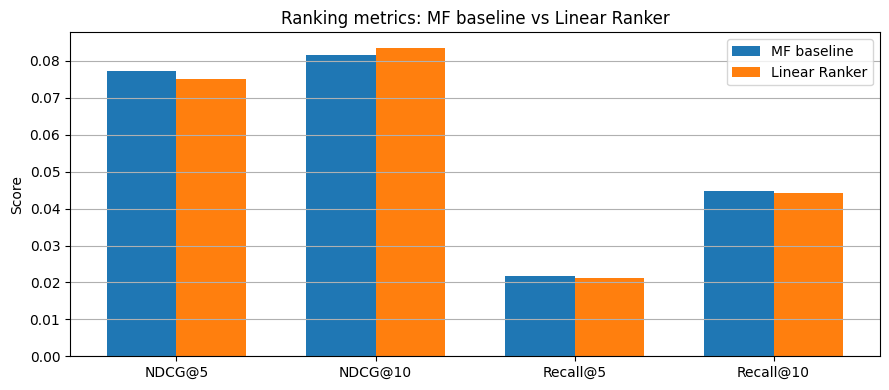

In [32]:
metrics = ["NDCG@5", "NDCG@10", "Recall@5", "Recall@10"]
x, width = np.arange(len(metrics)), 0.35

fig, ax = plt.subplots(figsize=(9, 4))
for k, (name, vals) in enumerate(results.items()):
    ax.bar(x + k * width, [vals[m] for m in metrics], width, label=name)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Ranking metrics: MF baseline vs Linear Ranker")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.show()

# [LTR] - MMR Diversity Reranking

In [33]:
# Item similarity via normalised MF embeddings (cosine)
Q_norm = Q_mf / (np.linalg.norm(Q_mf, axis=1, keepdims=True) + 1e-10)


def item_sim(i, j):
    return float(Q_norm[i] @ Q_norm[j])


def mmr_rerank(candidate_items, candidate_scores, K, alpha):
    """
    Maximal Marginal Relevance reranking.
    candidate_scores normalised to [0,1].
    alpha=0 -> pure relevance; alpha=1 -> pure diversity.
    """
    selected = []
    remaining = list(zip(candidate_items, candidate_scores))
    while len(selected) < K and remaining:
        if not selected:
            best = int(np.argmax([s for _, s in remaining]))
        else:
            mmr = [
                (1 - alpha) * s
                - alpha * max(item_sim(c, s_item) for s_item in selected)
                for c, s in remaining
            ]
            best = int(np.argmax(mmr))
        selected.append(remaining[best][0])
        remaining.pop(best)
    return selected


def diversity_at_k(ranked_items, K):
    items = list(ranked_items)[:K]
    if len(items) < 2:
        return 0.0
    sims = [
        item_sim(items[a], items[b])
        for a in range(len(items))
        for b in range(a + 1, len(items))
    ]
    return 1.0 - np.mean(sims)


print("MMR helpers defined.")

MMR helpers defined.


In [34]:
M = 50
K = 10
alphas = [0.0, 0.1, 0.4, 0.7, 1.0]

mmr_ndcg = {a: [] for a in alphas}
mmr_div = {a: [] for a in alphas}

for u in eval_users[: min(100, len(eval_users))]:
    rel = user_test_relevant[u]
    exclude = user_train_items.get(u, set())
    all_scores = np.array(
        [ranker_score(u, i) if i not in exclude else -np.inf for i in range(n_items)]
    )
    top_m = np.argsort(-all_scores)[:M]
    raw_s = all_scores[top_m]
    s_min, s_max = raw_s.min(), raw_s.max()
    norm_s = (raw_s - s_min) / (s_max - s_min + 1e-10)
    for alpha in alphas:
        ranked = mmr_rerank(top_m.tolist(), norm_s.tolist(), K, alpha)
        mmr_ndcg[alpha].append(ndcg_at_k(ranked, rel, K))
        mmr_div[alpha].append(diversity_at_k(ranked, K))

print("alpha | NDCG@10 | Diversity@10")
print("------+---------+-------------")
for a in alphas:
    print(f"{a:.1f}   | {np.mean(mmr_ndcg[a]):.4f}  | {np.mean(mmr_div[a]):.4f}")

alpha | NDCG@10 | Diversity@10
------+---------+-------------
0.0   | 0.0940  | 0.9304
0.1   | 0.0924  | 0.9372
0.4   | 0.0893  | 0.9604
0.7   | 0.0697  | 1.0029
1.0   | 0.0739  | 1.0309


In [35]:
div_vals  = [np.mean(mmr_div[a])  for a in alphas]
ndcg_vals = [np.mean(mmr_ndcg[a]) for a in alphas]

# plt.figure(figsize=(6, 4))
# plt.plot(div_vals, ndcg_vals, marker="o", linewidth=2)
# for a, d, n in zip(alphas, div_vals, ndcg_vals):
#     plt.annotate(f"a={a}", (d, n), textcoords="offset points", xytext=(5, 3), fontsize=9)
# plt.xlabel("Diversity@10 (avg pairwise dissimilarity)")
# plt.ylabel("NDCG@10")
# plt.title("Relevance-Diversity Tradeoff (MMR)")
# plt.grid(True); plt.tight_layout(); plt.show()


# Main Pipeline
> Candidate Generation → Ranking → MMR → User Feedback → EMA Update

Full interactive recommendation loop:
1. **Candidate generation** — all items the user has *not* seen in train
2. **Ranking** — score candidates with MF or LTR
3. **Reranking** — MMR on top-M candidates → diverse top-K list
4. **User feedback** — user picks one item (simulated via test ratings)
5. **State update** — EMA on user embedding: $p_u \leftarrow (1-\beta)\,p_u + \beta\,q_{i^*}$

In [36]:
# Load item titles for readable output
items_path = ML100K_DIR / "u.item"
item_titles = {}
with open(items_path, encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split("|")
        if len(parts) >= 2:
            raw_id = int(parts[0])
            if raw_id in item2idx:
                item_titles[item2idx[raw_id]] = parts[1]
print(f"Loaded {len(item_titles)} item titles")

Loaded 1682 item titles


In [37]:
def generate_candidates(u):
    """Stage 1: all items the user has not rated in train."""
    seen = user_train_items.get(u, set())
    return [i for i in range(n_items) if i not in seen]


def rank_candidates(u, candidates, scorer):
    """Stage 2: score and sort candidates."""
    scores = np.array([scorer(u, i) for i in candidates])
    order = np.argsort(-scores)
    return [candidates[k] for k in order], scores[order]


def rerank_mmr(items, scores, K, alpha):
    """Stage 3: MMR reranking on top-M candidates -> top-K diverse list."""
    M = min(50, len(items))
    top_items = items[:M]
    top_scores = scores[:M]
    s_min, s_max = top_scores.min(), top_scores.max()
    norm = (top_scores - s_min) / (s_max - s_min + 1e-10)
    return mmr_rerank(top_items, norm.tolist(), K, alpha)


def simulate_feedback(u, ranked_items):
	"""Stage 4: simulate user pick - random choice among top-10 items.
	Returns (chosen_item, rating_or_None).
	"""
	user_test = {i: r for i, r in zip(test_i[test_u == u], test_r[test_u == u])}

	top_n = min(10, len(ranked_items))
	chosen_item = int(rng.choice(ranked_items[:top_n]))
	rating = user_test.get(chosen_item, None)

	return chosen_item, rating


def update_user_state(u, i_selected, P, Q, beta=0.1):
    """Stage 5: EMA update of user embedding.
    p_u <- (1 - beta) * p_u + beta * q_{i*}
    """
    P[u] = (1 - beta) * P[u] + beta * Q[i_selected]

In [38]:
def pipeline_step(u, scorer, K=10, mmr_alpha=0.3, ema_beta=0.1, verbose=True):
    """
    Run one full recommendation turn for user u.
    Returns (recommended_items, chosen_item, rating).
    """
    # 1. Candidate generation
    candidates = generate_candidates(u)

    # 2. Ranking
    ranked_items, ranked_scores = rank_candidates(u, candidates, scorer)

    # 3. MMR reranking
    top_k = rerank_mmr(ranked_items, ranked_scores, K=K, alpha=mmr_alpha)

    # 4. User feedback
    chosen, rating = simulate_feedback(u, top_k)

    # 5. State update
    update_user_state(u, chosen, P_mf, Q_mf, beta=ema_beta)

    if verbose:
        print(f"User {u} — recommended {K} items, user picked:")
        title = item_titles.get(chosen, f"item_{chosen}")
        r_str = f"{rating:.0f}/5" if rating is not None else "unknown"
        print(f"  -> [{chosen}] {title}  (test rating: {r_str})")
        print(f"  Top-{K} list:")
        for rank, item in enumerate(top_k, 1):
            mark = " <-- picked" if item == chosen else ""
            title = item_titles.get(item, f"item_{item}")
            print(f"    {rank:2d}. {title}{mark}")

    return top_k, chosen, rating

In [43]:
# Multi-turn simulation for a single user
DEMO_USER = None
N_TURNS = 5
EMA_BETA = 0.1
MMR_ALPHA = 0.3


# Find a user where the model surfaces relevant items (look at first 10)
top_hits = -1
for candidate_user in eval_users[:10]:
    if not DEMO_USER:
        DEMO_USER = candidate_user
    rel = user_test_relevant[candidate_user]
    top10 = get_top_k(candidate_user, mf_scorer, K=10)
    hits = sum(1 for i in top10 if i in rel)
    if hits > top_hits:
        DEMO_USER = candidate_user
        top_hits = hits
    print(f"User {candidate_user}: {len(rel)} relevant items, {hits} hits in top-10")


# Reset to clean MF state for demo
P_sim = P_mf.copy()
Q_sim = Q_mf.copy()


# Wrap scorer to use sim state
def sim_ranker_score(u, i):
    return float(phi @ get_features(u, i, mu, bu_mf, bi_mf, P_sim, Q_sim))


def sim_update(u, i_selected):
    P_sim[u] = (1 - EMA_BETA) * P_sim[u] + EMA_BETA * Q_sim[i_selected]

print(f"=== {N_TURNS}-turn simulation for user {DEMO_USER} ===\n")
seen_in_sim = set()  # track items shown across turns
turn_ndcg = []

for turn in range(1, N_TURNS + 1):
    print(f"--- Turn {turn} ---")
    candidates = [
        i
        for i in range(n_items)
        if i not in user_train_items.get(DEMO_USER, set()) and i not in seen_in_sim
    ]
    scores_arr = np.array([sim_ranker_score(DEMO_USER, i) for i in candidates])
    order = np.argsort(-scores_arr)
    ranked_c = [candidates[k] for k in order]
    ranked_s = scores_arr[order]

    top_k = rerank_mmr(ranked_c, ranked_s, K=10, alpha=MMR_ALPHA)
    chosen, rating = simulate_feedback(DEMO_USER, top_k)

    title = item_titles.get(chosen, f"item_{chosen}")
    r_str = f"user gave {rating:.0f}/5" if rating is not None else "not in test"
    print(f"  Picked: {title}  ({r_str})")

    rel = user_test_relevant[DEMO_USER]
    ndcg = ndcg_at_k(top_k, rel, 10)
    turn_ndcg.append(ndcg)
    print(f"  NDCG@10 this turn: {ndcg:.4f}")

    seen_in_sim.update(top_k)
    sim_update(DEMO_USER, chosen)
    print()
    # print(len(user_test_relevant))       # should be ~700+
    # print(list(user_test_relevant.items())[:3])
    # print(eval_users[:5])
    # u = eval_users[0]
    # top10 = get_top_k(u, mf_scorer, K=10)
    # print(top10)
    # print(user_test_relevant[u])
    # print(any(i in user_test_relevant[u] for i in top10))

User 8: 8 relevant items, 0 hits in top-10
User 587: 23 relevant items, 1 hits in top-10
User 353: 26 relevant items, 1 hits in top-10
User 879: 34 relevant items, 1 hits in top-10
User 636: 3 relevant items, 1 hits in top-10
User 71: 26 relevant items, 1 hits in top-10
User 652: 15 relevant items, 1 hits in top-10
User 685: 18 relevant items, 2 hits in top-10
User 327: 25 relevant items, 1 hits in top-10
User 915: 29 relevant items, 1 hits in top-10
=== 5-turn simulation for user 685 ===

--- Turn 1 ---
  Picked: Maya Lin: A Strong Clear Vision (1994)  (not in test)
  NDCG@10 this turn: 0.1546

--- Turn 2 ---
  Picked: Vertigo (1958)  (not in test)
  NDCG@10 this turn: 0.2201

--- Turn 3 ---
  Picked: Citizen Kane (1941)  (user gave 5/5)
  NDCG@10 this turn: 0.1488

--- Turn 4 ---
  Picked: Thin Man, The (1934)  (not in test)
  NDCG@10 this turn: 0.0784

--- Turn 5 ---
  Picked: Godfather: Part II, The (1974)  (not in test)
  NDCG@10 this turn: 0.0000



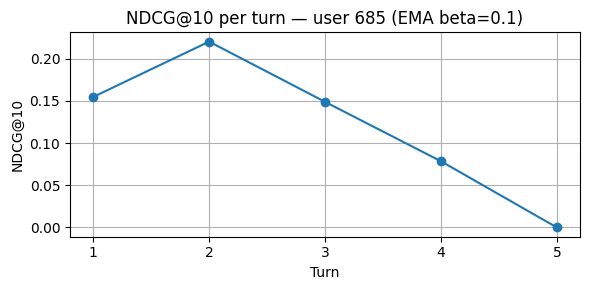

In [44]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, N_TURNS + 1), turn_ndcg, marker="o")
plt.xlabel("Turn")
plt.ylabel("NDCG@10")
plt.title(f"NDCG@10 per turn — user {DEMO_USER} (EMA beta={EMA_BETA})")
plt.xticks(range(1, N_TURNS + 1))
plt.grid(True)
plt.tight_layout()
plt.show()